# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

In [ ]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [ ]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

In [3]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[Mac.dhcp.lbnl.us:23561] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.Mac.501/jf.0/1768095744/sm_segment.Mac.501.69630000.0 could be created.


[000000.00] [0/1] 04-30 14:08  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [4]:
def propose_fiducial():
    propose_fiducial = {}

    use_ell2 = True

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 1e-2, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': use_ell2, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': use_ell2, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['ELGxQSO']
      
    return propose_fiducial

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

pks, windows, covs, mocks, zeffs = {}, {}, {}, {}, {}
for tracer in tracers_to_read:
    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, add_ic=True, 
                                       aladr1=True, weight_type_mocks='default-fkp-oqe', **fiducial[short_tracer])
    
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])
    
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except ValueError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
   
    if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
    pks[short_tracer], windows[short_tracer], covs[short_tracer], mocks[short_tracer] = pk, window, cov, mock

    zeffs[short_tracer] = {}
    zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
    try: 
        zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
    except ValueError:
        pass

[000000.02] [0/1] 04-30 14:08  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000004.56] [0/1] 04-30 14:08  FIT PNG                   INFO     After rebinning and k range selection: 29 and 13 data points.
[000004.57] [0/1] 04-30 14:08  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000009.02] [0/1] 04-30 14:08  FIT PNG                   INFO     After rebinning and k range selection: 20 and 13 data points.
[000009.03] [0/1] 04-30 14:08  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000013.53] [0/1] 04-30 14:08  FIT PNG                   INFO     After rebinning and k range selection: 29 and 13 data points.
[000013.54] [0/1] 04-30 14:08  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000018.19] [0/1] 04-30 14:08  FIT PNG                   INF

In [5]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

observables, likelihoods, profilers = {}, {}, {}
for tracer in tracers:
    observables[tracer], likelihoods[tracer] = get_observable_and_likelihood(pks[tracer], windows[tracer], mocks[tracer], 
                                                                             tracer, zeffs, nickname=tracer, engine='camb', **kwargs)
    profilers[tracer] = run_profiler(likelihoods[tracer])

[000027.55] [0/1] 04-30 14:08  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000027.66] [0/1] 04-30 14:08  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000027.71] [0/1] 04-30 14:08  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000027.79] [0/1] 04-30 14:08  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 998 observations.
[000027.79] [0/1] 04-30 14:08  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9569.
[000029.12] [0/1] 04-30 14:08  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 998 observations, varying 4 parameters.
[000029.12] [0/1] 04-30 14:08  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0344.
[000029.58] [0/1] 04-30 14:08  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.s

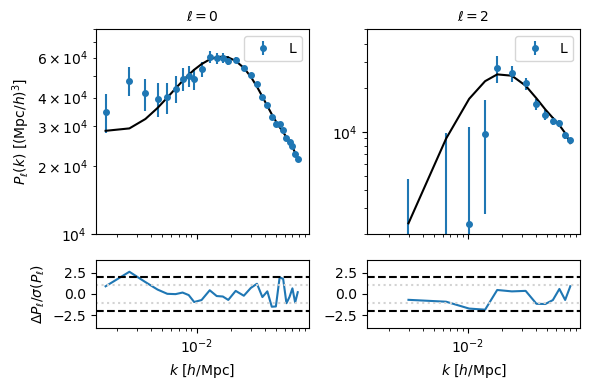

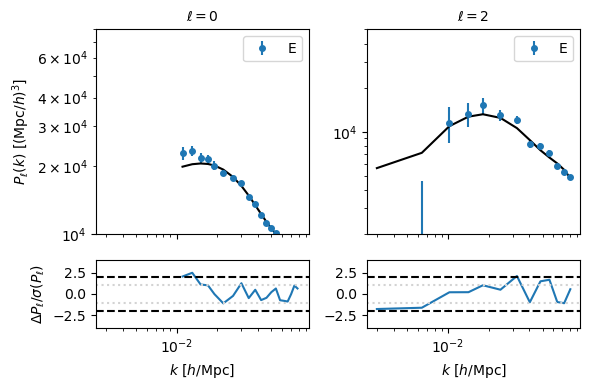

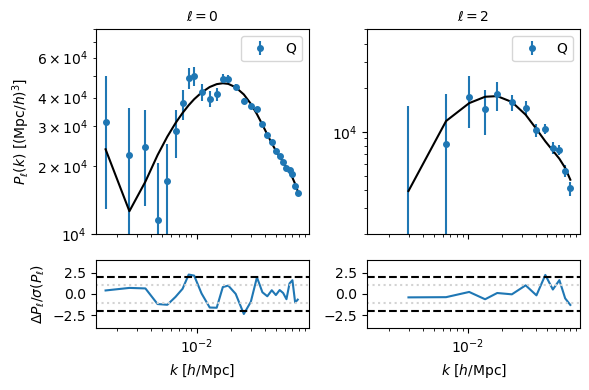

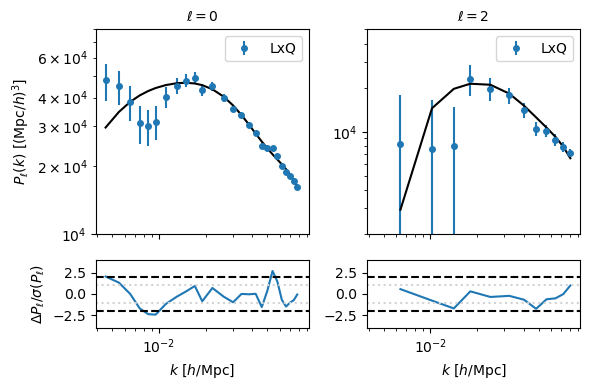

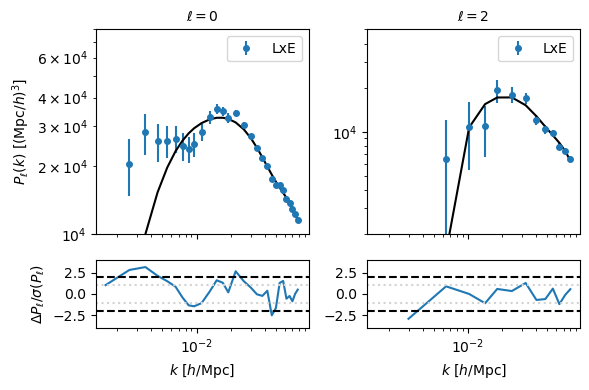

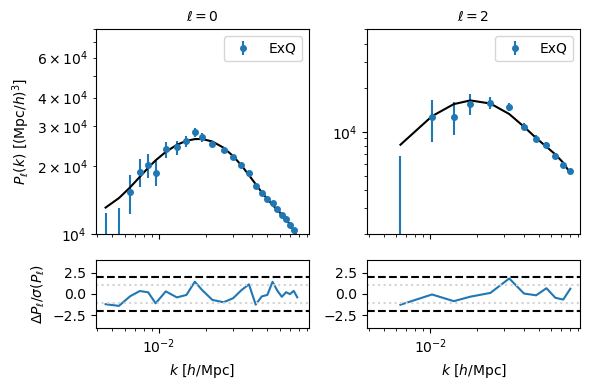

In [6]:
#plot_observables(observables)
for tracer in observables.keys():
    plot_observables({tracer: observables[tracer]})

[000408.77] [0/1] 04-30 14:15  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000409.03] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 122 points built from 998 observations.
[000409.03] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.8766.
[000409.63] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 122 points built from 998 observations, varying 9 parameters.
[000409.63] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1166.
[000409.64] [0/1] 04-30 14:15  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000410.07] [0/1] 04-30 14:15  MinuitProfiler            INFO     Successfully jit input likel

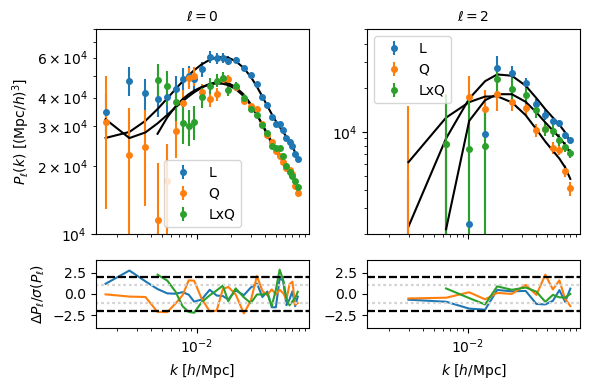

[000415.11] [0/1] 04-30 14:15  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000415.48] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 202 points built from 998 observations.
[000415.48] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7964.
[000420.86] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 202 points built from 998 observations, varying 14 parameters.
[000420.86] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.2141.
[000420.93] [0/1] 04-30 14:15  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_ELGxQSO_ell0xQSO_ELGxQSO_ell0.sn0', 'ELG_ELGxQSO_ell0.b1', 'QSO_ELGxQSO_ell0.sigmas', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO

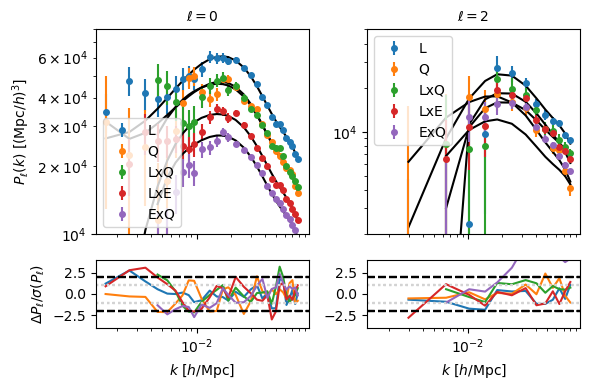

[000436.17] [0/1] 04-30 14:15  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000436.66] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 235 points built from 998 observations.
[000436.66] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7633.
[000446.39] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     Covariance matrix with 235 points built from 998 observations, varying 16 parameters.
[000446.39] [0/1] 04-30 14:15  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.2600.
[000446.50] [0/1] 04-30 14:15  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_ELGxQSO_ell0xQSO_ELGxQSO_ell0.sn0', 'QSO_ELGxQSO_ell0.sigmas', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'QSO_ell

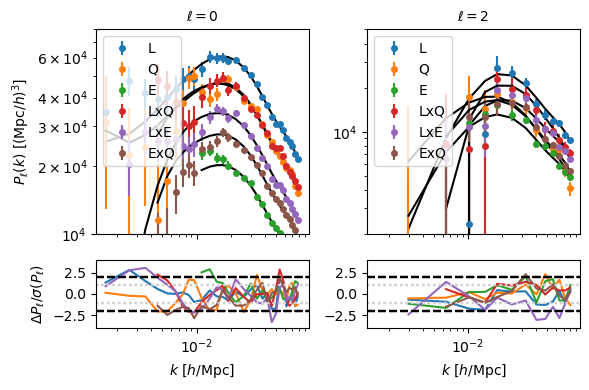

In [8]:
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, observables, mocks, zeffs, fiducial)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [20]:
## PLUS J4IA PAS UN BEAU PK ALORS QUE AVANT JEN AVAIS UN ! KEPASA ??   --> COMPARER AVEC DR2 FKP 

In [ ]:
# Run mcmc:
samplers = {}

for tracer in likelihoods.keys():
    logger.info(f'Run MCMC for {tracer=}:')
    samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=10000)

[001077.16] [0/1] 04-30 14:26  FIT PNG                   INFO     Run MCMC for tracer='LRGxLRG':
[001077.16] [0/1] 04-30 14:26  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[None]
[001077.20] [0/1] 04-30 14:26  EmceeSampler              INFO     Successfully vmap input likelihood.
[001077.38] [0/1] 04-30 14:26  EmceeSampler              INFO     Successfully jit input likelihood.
[001112.55] [0/1] 04-30 14:26  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[001145.80] [0/1] 04-30 14:27  Chain                     INFO     Saving tmp/mcmc_output_0.npy.
[001145.81] [0/1] 04-30 14:27  FIT PNG                   INFO     Run MCMC for tracer='ELGxELG':
[001145.81] [0/1] 04-30 14:27  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas'].
[None]
[001145.84] [0/1] 04-30 14:27  EmceeSampler              INFO     Successfully vmap input likelihood.

Nbr points for tracer='LRGxLRG': 14000
Nbr points for tracer='ELGxELG': 14000
Nbr points for tracer='QSOxQSO': 14000
Nbr points for tracer='LRGxQSO': 14000
Nbr points for tracer='LRGxELG': 14000
Nbr points for tracer='ELGxQSO': 14000
Nbr points for tracer='LRGxLRG-QSOxQSO-LRGxQSO': 30800
Nbr points for tracer='LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO': 50400
Nbr points for tracer='LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO': 56000
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


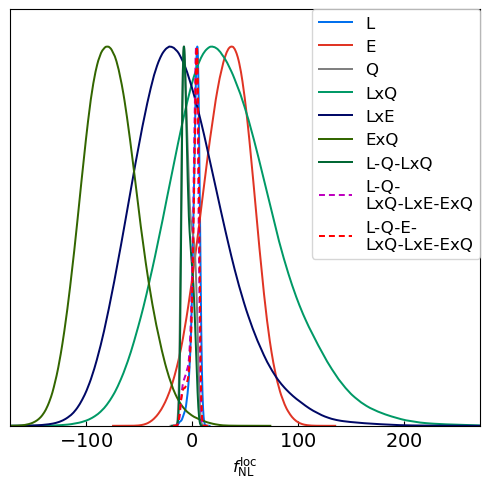

In [26]:
from desilike.samples import Chain
burnin, thin = 0.3, 10

translator = {'LRGxLRG': 'L', 'ELGxELG': 'E', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'LRGxELG': 'LxE', 'ELGxQSO': 'ExQ'}
translator['LRGxLRG-QSOxQSO-LRGxQSO'] = 'L-Q-LxQ'
translator['LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO'] = 'L-Q-\nLxQ-LxE-ExQ'
translator['LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO'] = 'L-Q-E-\nLxQ-LxE-ExQ'

chains = {}
for tracer in samplers.keys():
     # to load chains from a disk:
     #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])
     
     chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
     print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

from tools import get_getdist_plotter, plot_triangle
g = get_getdist_plotter(fig_width_inch=5)

plot_triangle([chains[tracer] for tracer in chains.keys()],  ['fnl_loc'], legend_labels=list(translator[tracer] for tracer in chains.keys()), 
              xlabels=[r'$f_{\rm NL}^{\rm loc}$'], g=g)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


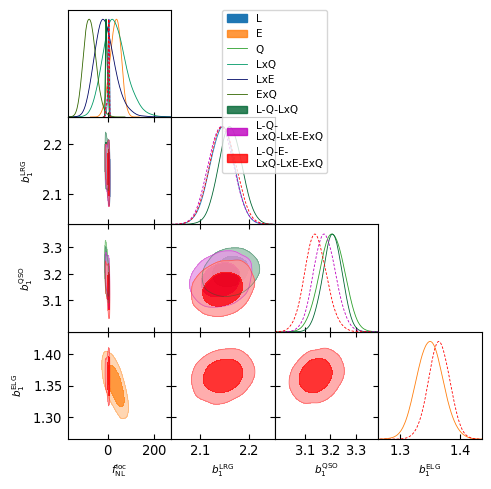

In [27]:
params = ['fnl_loc', 'LRG_ell0.b1', 'QSO_ell0.b1', 'ELG_ell0.b1']
xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm LRG}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm ELG}$']
plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(translator[tracer] for tracer in chains.keys()), xlabels=xlabels, 
              filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

## Display the combined analytical covariance matrix:

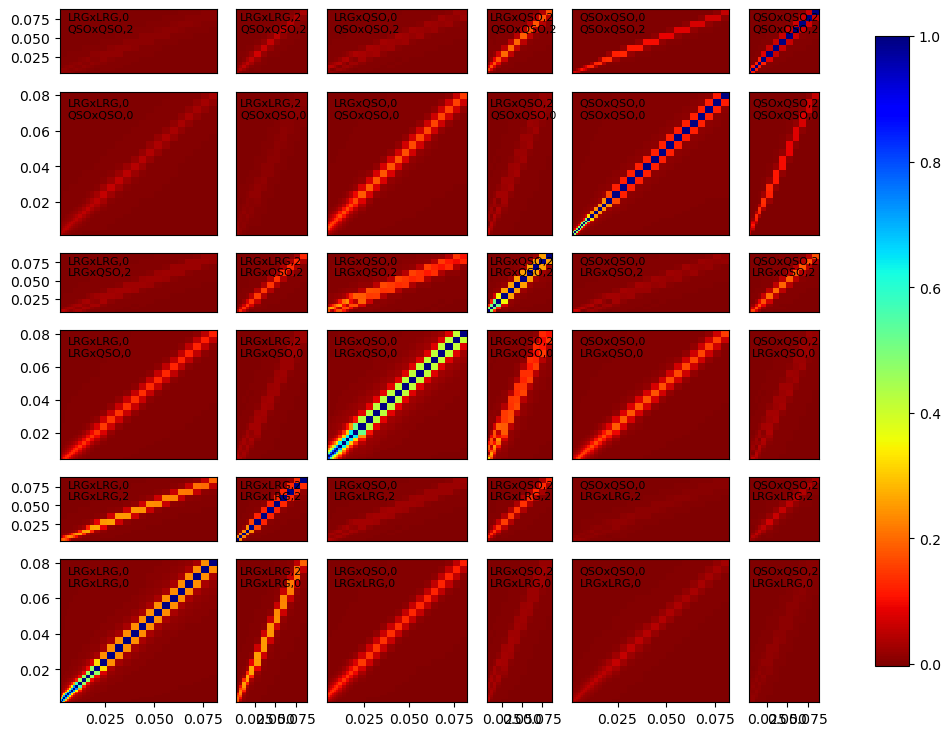

In [ ]:
def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()

from tools import combine_analytical_covariances

order = ['LRGxLRG', 'LRGxQSO', 'QSOxQSO']

combined_cov = combine_analytical_covariances(pks, covs, order=order, fiducial=fiducial)
plot_corr(combined_cov)